<a href="https://colab.research.google.com/github/naruedisriparn-sketch/DSP/blob/main/Y3Lab2_worksheet2256_2272.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Year 3 · Lab 2: Data over Sound
### *ส่งข้อมูลผ่านเสียง: สร้างโมเด็มของคุณเอง*
**DSP Lab Series · team of 3 · 100 points · about 3 hours / ทีมละ 3 คน ประมาณ 3 ชั่วโมง**

Today your team builds an **acoustic modem**: a transmitter that turns a text message into sound, and a receiver that turns a recording of that sound back into text — through a real room, from a laptop speaker to a phone microphone.
*วันนี้ทีมของคุณจะสร้างโมเด็มเสียง: ฝั่งส่งแปลงข้อความเป็นเสียง ฝั่งรับแปลงเสียงที่อัดได้กลับเป็นข้อความ ผ่านห้องจริง จากลำโพง laptop ไปไมค์มือถือ*

| Part | Topic | หัวข้อ | Points | Suggested time |
|---|---|---|---|---|
| 1 | Text ↔ bits | ข้อความ ↔ บิต | 10 | 20 min |
| 2 | Transmitter | ฝั่งส่ง | 20 | 35 min |
| 3 | Receiver | ฝั่งรับ | 30 | 50 min |
| 4 | Over the air | ส่งผ่านอากาศจริง | 25 | 45 min |
| 5 | Challenge | ภารกิจท้าทาย | 15 | 30 min |

**The system you are building / ระบบที่จะสร้าง**
```
text ─► bits (UTF-8 + length byte) ─► FSK tones + chirp ─► speaker ─► room ─► mic ─► find chirp (correlation) ─► tone energy per bit ─► bits ─► text
```

> 🔊 **Be a good neighbour / มารยาท:** play at **medium volume**, take turns, or use the corridor. 🔓 Anyone with this code can decode your message — **never send passwords**. *เปิดเสียงปานกลาง และห้ามส่งรหัสผ่าน*

### Rules / กติกา
Fill in every `# TODO`, answer every ✍️ cell, and give every plot axis labels with units (plot text in English). Before submitting: **Runtime › Restart and run all** → **File › Download .ipynb** → name it `Y3Lab2_<teamID>.ipynb` → upload with your report `Y3Lab2_Report_<teamID>.pdf` to [LMS] before [day, time].

## Part 0 · Setup — run this first
*ส่วนที่ 0 · ตั้งค่า — รัน cell นี้ก่อนเสมอ*

In [2]:
TEAM_ID = "2256_2272"          # TODO: e.g. "T07"
MEMBERS = ["naruedi (2256)", "Pawornrat (2272)"]      # TODO: ["Name 1 (ID)", "Name 2 (ID)", "Name 3 (ID)"]

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, spectrogram, fftconvolve
from scipy.io import wavfile
from IPython.display import Audio, display

FS = 44100                      # sampling rate used everywhere in this lab
F0, F1 = 1800.0, 2600.0         # tone for bit 0 / bit 1
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

def check(condition, message):
    """Self-check helper: ✅ = correct, ❌ = not yet. Never stops the notebook."""
    try:
        ok = bool(condition)
    except Exception as e:
        ok = False; message += f"  (error: {e})"
    print(("✅ " if ok else "❌ ") + message)

check(len(TEAM_ID) > 0 and len(MEMBERS) >= 2, "team filled in / กรอกข้อมูลทีมแล้ว")

✅ team filled in / กรอกข้อมูลทีมแล้ว


### Helpers — run, do not edit / ฟังก์ชันช่วย ไม่ต้องแก้
- `taper(n)`, `make_chirp()` — building blocks for your transmitter
- `room_channel(x, snr_db, drr_db)` — a **simulated classroom**: unknown delay, reverb and noise. Use it to test before going over the air.
- `at_distance(d)` — the `(snr_db, drr_db)` our room model predicts at `d` metres
- `save_wav(x, name)`, `load_recording(path)` — write a WAV to play; read any phone recording (m4a, mp3, wav…) as mono 44.1 kHz
- `record(seconds)` — record with the laptop microphone in Colab (if you play from the phone instead)

In [3]:
import os, subprocess
from base64 import b64decode
try:
    from google.colab import files as _files
    from google.colab.output import eval_js
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

CHIRP_T, GAP_T = 0.15, 0.05

def taper(n, frac=0.05):
    """Raised-cosine fade in/out over `frac` of the length (avoids clicks)."""
    w = np.ones(n); m = max(1, int(frac * n))
    ramp = 0.5 - 0.5 * np.cos(np.pi * np.arange(m) / m)
    w[:m] = ramp; w[-m:] = ramp[::-1]
    return w

def make_chirp(fs=FS, T=CHIRP_T, fa=1000.0, fb=4000.0):
    """Linear chirp from fa to fb Hz in T seconds — our 'start of message' marker."""
    t = np.arange(int(T * fs)) / fs
    return np.sin(2 * np.pi * (fa * t + (fb - fa) / (2 * T) * t**2)) * taper(len(t))

def room_impulse(fs=FS, rt60=0.25, drr_db=5.0, seed=0):
    r = np.random.default_rng(seed); n = int(1.2 * rt60 * fs); t = np.arange(n) / fs
    tail = r.normal(0, 1, n) * np.exp(-6.9 * t / rt60); tail[: int(0.001 * fs)] = 0
    tail *= np.sqrt(10 ** (-drr_db / 10) / np.sum(tail**2)); tail[0] = 1.0
    return tail

def room_channel(x, snr_db=10.0, drr_db=5.0, rt60=0.25, fs=FS, seed=0):
    """Simulated classroom: unknown delay + reverb (drr_db=None → no reverb) + white noise at snr_db."""
    r = np.random.default_rng(seed + 1000)
    y = 0.3 * fftconvolve(x, room_impulse(fs, rt60, drr_db, seed))[: len(x) + int(0.2 * fs)] if drr_db is not None else 0.3 * x
    y = np.concatenate([np.zeros(int(r.uniform(0.2, 0.5) * fs)), y, np.zeros(int(0.2 * fs))])
    return y + r.normal(0, np.sqrt(np.mean((0.3 * x) ** 2) / 10 ** (snr_db / 10)), len(y))

def at_distance(d_m, snr_1m=10.0, drr_1m=6.0):
    """Direct sound falls 6 dB per doubling of distance; reverb stays. Returns (snr_db, drr_db)."""
    loss = 20 * np.log10(d_m)
    return snr_1m - loss, drr_1m - loss

def save_wav(x, name, fs=FS, download=False):
    wavfile.write(name, fs, (0.9 * x / np.max(np.abs(x)) * 32767).astype(np.int16))
    if download and IN_COLAB: _files.download(name)
    return name

def load_recording(path, fs=FS):
    """Any audio file → mono float at fs (uses ffmpeg, available in Colab)."""
    subprocess.run(["ffmpeg", "-y", "-loglevel", "quiet", "-i", path, "-ac", "1", "-ar", str(fs), "_rec.wav"], check=True)
    r, d = wavfile.read("_rec.wav")
    d = d.astype(float) / (np.iinfo(d.dtype).max + 1 if np.issubdtype(d.dtype, np.integer) else 1)
    return d

def upload_file():
    if not IN_COLAB: raise RuntimeError("upload works in Colab only")
    return list(_files.upload().keys())[0]

_REC_JS = """
async function recordAudio(ms) {
  const s = await navigator.mediaDevices.getUserMedia({audio: {echoCancellation:false, noiseSuppression:false, autoGainControl:false}});
  const rec = new MediaRecorder(s); const ch = []; rec.ondataavailable = e => ch.push(e.data);
  const done = new Promise(r => rec.onstop = r); rec.start(); await new Promise(r => setTimeout(r, ms)); rec.stop(); await done;
  s.getTracks().forEach(t => t.stop()); const b = new Uint8Array(await new Blob(ch).arrayBuffer());
  let str = ''; for (let i = 0; i < b.length; i++) str += String.fromCharCode(b[i]); return btoa(str);
}"""
def record(seconds=5):
    """Record from the laptop microphone in Colab (noise suppression off) → mono float at FS."""
    if not IN_COLAB: raise RuntimeError("record() works in Colab only")
    from IPython.display import Javascript
    display(Javascript(_REC_JS)); print(f"🔴 recording {seconds} s — start the sender now")
    open("_rec.webm", "wb").write(b64decode(eval_js(f"recordAudio({int(seconds*1000)})")))
    return load_recording("_rec.webm")

print("Helpers ready. In Colab:", IN_COLAB)

Helpers ready. In Colab: True


---
## Part 1 · Text ↔ bits (10 pts)
*ส่วนที่ 1 · ข้อความ ↔ บิต*

### 1.1 Encode and decode (5 pts)
- `text_to_bits(s)`: UTF-8 bytes → array of 0/1 (most significant bit first). 💡 `s.encode("utf-8")`, `np.frombuffer(..., dtype=np.uint8)`, `np.unpackbits`
- `bits_to_text(b)`: the reverse. Use `errors="replace"` so broken bytes show as � instead of crashing. 💡 `np.packbits`, `.tobytes().decode(...)`

In [7]:
import numpy as np

def text_to_bits(s):
    data = np.frombuffer(s.encode("utf-8"), dtype=np.uint8)
    return np.unpackbits(data)          # MSB first, 8 bits per byte

def bits_to_text(b):
    b = np.asarray(b, dtype=np.uint8)
    data = np.packbits(b)               # MSB first, zero-pads the last byte if needed
    return data.tobytes().decode("utf-8", errors="replace")

### 1.2 Add a length byte (3 pts)
`frame_bits(text)`: one byte holding the **number of payload bytes**, followed by the payload bits. Raise `ValueError` if the message is longer than 255 bytes.
*ไบต์แรกบอกจำนวนไบต์ของข้อความ ตามด้วยบิตของข้อความ*

In [9]:
import numpy as np

def frame_bits(text):
    # แปลงข้อความให้เป็นไบต์ก่อน เพื่อเช็คความยาว
    encoded_text = text.encode('utf-8')
    if len(encoded_text) > 255:
        raise ValueError("Message is longer than 255 bytes.")

    # ดึง payload เป็นบิต
    payload = text_to_bits(text)

    # สร้างไบต์บอกจำนวนไบต์ (1 ไบต์ / 8 บิต) แล้วแปลงเป็นอาเรย์ของบิต
    length_byte = np.array([len(encoded_text)], dtype=np.uint8)
    length_bits = np.unpackbits(length_byte)

    # รวม length_bits เข้ากับ payload bits
    return np.concatenate((length_bits, payload))

### 1.3 Questions (2 pts)
(a) “สวัสดี” has 6 characters but “HELLO” has 5. Which takes longer to send, and by how many bits? *ข้อความไหนใช้เวลาส่งนานกว่า กี่บิต*
(b) Why can one length byte describe at most 255 bytes? *ทำไมไบต์เดียวบอกได้สูงสุด 255*

✍️ **Your answer / คำตอบ:**

(a) “สวัสดี” has 6 characters but “HELLO” has 5. Which takes longer to send, and by how many bits?   คำตอบ: คำว่า “สวัสดี” ใช้เวลาส่งนานกว่า โดยใช้บิตมากกว่า 13 บิต (เนื่องจากอักษรภาษาไทยในรหัส UTF-8 ใช้ 3 ไบต์ต่อตัวอักษร 6 ตัว = 18 ไบต์ หรือ 144 บิต รวมกับ length byte อีก 1 ไบต์/8 บิต เป็น 152 บิต ส่วน “HELLO” ใช้ 5 ตัวอักษรภาษาอังกฤษแบบ ASCII คือ 5 ไบต์ หรือ 40 บิต รวม length byte เป็น 48 บิต ทำให้ “สวัสดี” ใช้บิตมากกว่า $152 - 48 = 104$ บิต ซึ่งแปลว่าใช้เวลาส่งนานกว่า)

(b)  Why can one length byte describe at most 255 bytes?   คำตอบ: เพราะไบต์หนึ่งประกอบด้วย 8 บิต ซึ่งสามารถแทนค่าตัวเลขฐานสองได้ตั้งแต่ $0$ ถึง $2^8 - 1$ (หรือจาก $0$ ถึง $255$) จึงทำให้สามารถบอกขนาดความยาวได้สูงสุดที่ 255 ไบต์ครับ

---
## Part 2 · Transmitter (20 pts)
*ส่วนที่ 2 · ฝั่งส่ง*

$$s(t) = \sin(2\pi f_b t),\quad f_b = f_0 = 1800\ \text{Hz}\ (b=0),\ \ f_1 = 2600\ \text{Hz}\ (b=1) \qquad R = \frac{1}{T_b}$$

### 2.1 `fsk_modulate` (8 pts)
For each bit, generate `round(FS / baud)` samples of a sine at `F0` or `F1`, **multiplied by `taper(n)`**, and join them. Every bit starts at phase 0.
*แต่ละบิตสร้างไซน์ความถี่ F0 หรือ F1 ยาว FS/baud sample คูณด้วย taper แล้วต่อกัน*

In [13]:
import numpy as np

def fsk_modulate(bits, baud, fs=FS, f0=1800, f1=2600):
    ns = int(round(fs / baud))
    t = np.arange(ns) / fs
    modulated_signal = []

    for bit in bits:
        # เลือกความถี่ตามค่าของบิต (0 ใช้ f0, 1 ใช้ f1)
        freq = f1 if bit == 1 else f0

        # สร้างคลื่นไซน์เริ่มต้นที่ phase 0 คูณด้วย taper(ns)
        sine_wave = np.sin(2 * np.pi * freq * t) * taper(ns)
        modulated_signal.append(sine_wave)

    # รวมสัญญาณของทุกบิตเข้าด้วยกันเป็นอาเรย์เดียว
    return np.concatenate(modulated_signal)

### 2.2 `transmit` — build a whole frame (6 pts)
Concatenate: 0.1 s silence · `make_chirp()` · `GAP_T` s silence · `fsk_modulate(frame_bits(text), baud)` · 0.1 s silence. Scale so the peak is 0.8.
*ต่อ: เงียบ 0.1 s · chirp · เงียบ GAP_T · บิต · เงียบ 0.1 s แล้วปรับให้ค่าสูงสุดเป็น 0.8*

In [14]:
import numpy as np

def transmit(text, baud=50, fs=FS):
    # 1. สร้างช่วงเงียบ 0.1 วินาที
    silence_01 = np.zeros(int(0.1 * fs))

    # 2. สร้างช่วงเงียบ GAP_T วินาที
    gap_silence = np.zeros(int(GAP_T * fs))

    # 3. เรียกใช้ฟังก์ชัน make_chirp() และ fsk_modulate()
    chirp_signal = make_chirp()
    modulated_data = fsk_modulate(frame_bits(text), baud, fs=fs)

    # 4. นำมา Concatenate ต่อกันตามลำดับ
    # (0.1 s silence -> chirp -> GAP_T s silence -> modulated data -> 0.1 s silence)
    full_frame = np.concatenate([
        silence_01,
        chirp_signal,
        gap_silence,
        modulated_data,
        silence_01
    ])

    # 5. ปรับสเกล (Scale) ให้ค่าแอมพลิจูดสูงสุด (peak) เป็น 0.8
    peak = np.max(np.abs(full_frame))
    if peak > 0:
        full_frame = full_frame * (0.8 / peak)

    return full_frame

### 2.3 Look at it (4 pts)
Plot the spectrogram of `tx` (`scipy.signal.spectrogram(tx, FS, nperseg=1024, noverlap=896)`, `pcolormesh` in dB, 0–5000 Hz). Mark where the chirp, the length byte and the payload are.
*plot spectrogram 0–5000 Hz แล้วระบุตำแหน่ง chirp, ไบต์ความยาว และข้อความ*

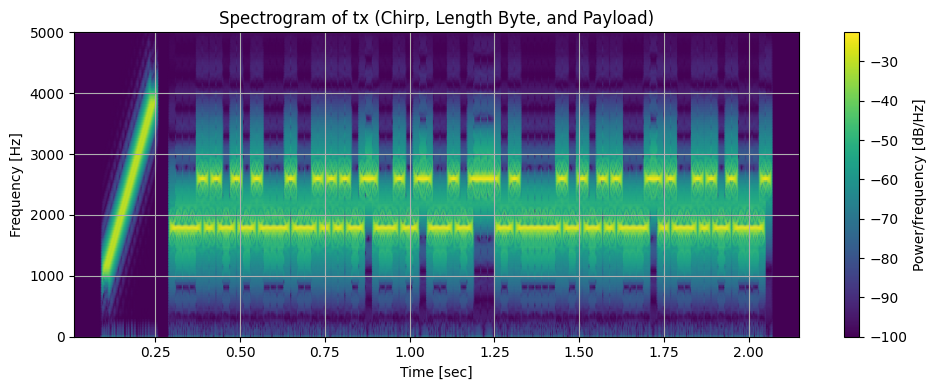

In [17]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# คำนวณ Spectrogram
f, t_spec, Sxx = spectrogram(tx, fs=FS, nperseg=1024, noverlap=896)

# พล็อตด้วย pcolormesh
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.ylim(0, 5000)
plt.title('Spectrogram of tx (Chirp, Length Byte, and Payload)')
plt.colorbar(label='Power/frequency [dB/Hz]')

plt.tight_layout()
plt.show()

### 2.4 Questions (2 pts)
(a) What is the bit rate if one bit lasts 5 ms? *ถ้าบิตละ 5 ms ความเร็วเท่าไร*
(b) Our tones are 800 Hz apart. Using Δf = k/T_b, up to what bit rate are they still orthogonal (k ≥ 1)? *เสียงห่างกัน 800 Hz ยัง orthogonal ได้ถึงกี่ bit/s*

✍️ **Your answer / คำตอบ:**

(a)  ความเร็วบิต (bit rate หรือ $R$) หาได้จากส่วนกลับของระยะเวลาในหนึ่งบิต ($T_b$) โดยถ้าหนึ่งบิตใช้เวลา $5\text{ ms}$ ($0.005\text{ s}$) จะได้อัตราเร็วบิตเท่ากับ $R = \frac{1}{0.005\text{ s}} = \mathbf{200\text{ bit/s}}$

(b) จากสูตรความต่างของความถี่ $\Delta f = \frac{k}{T_b}$ และเนื่องจาก bit rate คือ $R = \frac{1}{T_b}$ (หรือเขียนได้ว่า $\Delta f = k \cdot R$) เมื่อกำหนดให้ความต่างของความถี่เท่ากับ $800\text{ Hz}$ และเงื่อนไขความเป็น orthogonal ขั้นต่ำคือ $k = 1$ จะได้ความเร็วบิตสูงสุดที่ยังคง orthogonal คือ $R = \frac{\Delta f}{1} = \frac{800}{1} = \mathbf{800\text{ bit/s}}$

---
## Part 3 · Receiver (30 pts)
*ส่วนที่ 3 · ฝั่งรับ*

$$r[k] = \sum_n y[n+k]\,p[n] \qquad\qquad E_i = \Big|\sum_{n=0}^{N_b-1} y[n]\,e^{-j2\pi f_i n/f_s}\Big| \qquad \hat b = \begin{cases}1 & E_1 > E_0\\ 0 & \text{otherwise}\end{cases}$$

First, a test recording from the simulated room / *สัญญาณทดสอบจากห้องจำลอง:*

In [19]:
import numpy as np
from scipy.signal import correlate

def find_start(y):
    # 1. สร้าง chirp สัญญาณต้นแบบ
    chirp = make_chirp()

    # 2. Correlate สัญญาณ y กับ chirp ด้วย mode="valid" และ method="fft"
    c = correlate(y, chirp, mode="valid", method="fft")

    # 3. หา index ของค่าที่มากที่สุดในค่าสัมบูรณ์ของ c (|c|) ซึ่งคือจุดเริ่มต้นของ chirp
    chirp_start_idx = np.argmax(np.abs(c))

    # 4. บิตแรกเริ่มต้นหลังจาก chirp และเว้นระยะด้วย GAP_T
    first_bit_idx = chirp_start_idx + len(chirp) + int(GAP_T * FS)

    return first_bit_idx, c

### 3.1 `find_start` (8 pts)
Correlate `y` with `make_chirp()` (`correlate(y, chirp, mode="valid", method="fft")`). The index of the largest `|c|` is where the chirp **starts**; the first bit begins `len(chirp) + int(GAP_T*FS)` samples later. Return that index and `c`.
*หาจุดเริ่มของบิตแรกด้วย correlation กับ chirp*

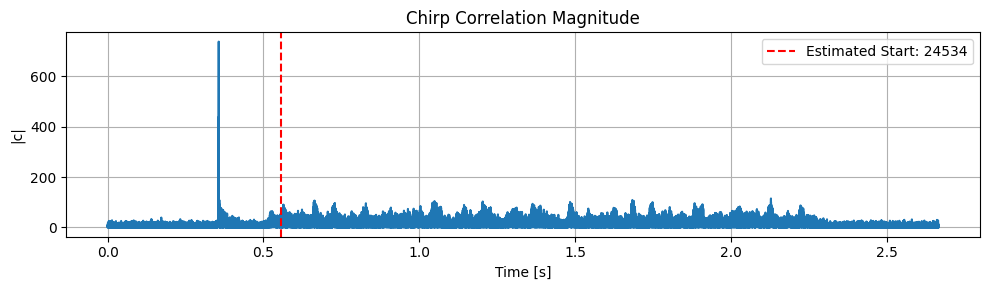

In [22]:
import numpy as np
from scipy.signal import correlate
import matplotlib.pyplot as plt

def find_start(y, fs=FS):
    pre = make_chirp(fs)
    # Correlate สัญญาณ y กับ pre (chirp)
    c = correlate(y, pre, mode="valid", method="fft")

    # หาตำแหน่ง index ที่มีค่าสัมบูรณ์สูงสุด
    chirp_start_idx = np.argmax(np.abs(c))

    # คำนวณจุดเริ่มต้นของบิตแรกตามที่โจทย์กำหนด
    start_idx = chirp_start_idx + len(pre) + int(GAP_T * fs)

    return start_idx, c

start, c = find_start(rx_test)

# พล็อต |c| เทียบกับเวลา (วินาที)
time_axis = np.arange(len(c)) / FS
plt.figure(figsize=(10, 3))
plt.plot(time_axis, np.abs(c))
plt.axvline(start / FS, color='r', linestyle='--', label=f'Estimated Start: {start}')
plt.xlabel("Time [s]")
plt.ylabel("|c|")
plt.title("Chirp Correlation Magnitude")
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 `tone_energy` and `demod_bits` (10 pts)
- `tone_energy(seg, f)`: $E = |\sum_n seg[n]\,e^{-j2\pi f n/f_s}|$
- `demod_bits(y, start, nbits, baud)`: cut `nbits` consecutive segments of `round(FS/baud)` samples from `start`; decide 1 if the energy at `F1` is larger. Return `bits, e0, e1` (arrays).

In [23]:
import numpy as np

def tone_energy(seg, f, fs=FS):
    # คำนวณตามสูตร E_i = | sum(seg[n] * exp(-j * 2 * pi * f * n / fs)) |
    n = np.arange(len(seg))
    energy = np.abs(np.sum(seg * np.exp(-1j * 2 * np.pi * f * n / fs)))
    return energy

def demod_bits(y, start, nbits, baud, fs=FS):
    ns = int(round(fs / baud))
    bits, e0s, e1s = [], [], []

    for i in range(nbits):
        # ตัดสัญญาณในช่วงของแต่ละบิต
        seg = y[start + i * ns : start + (i + 1) * ns]

        # คำนวณพลังงานที่ความถี่ F0 และ F1
        e0 = tone_energy(seg, F0, fs)
        e1 = tone_energy(seg, F1, fs)

        e0s.append(e0)
        e1s.append(e1)

        # ตัดสินใจเลือกบิต: ถ้าร่าง E1 > E0 ให้เป็น 1, นอกนั้นเป็น 0
        bit = 1 if e1 > e0 else 0
        bits.append(bit)

    return np.array(bits, dtype=np.uint8), np.array(e0s), np.array(e1s)

### 3.3 `receive` — the whole receiver (6 pts)
`find_start` → decode **8 header bits** → number of bytes → decode `8 × nbytes` payload bits → `bits_to_text`. Return `(text, payload_bits)`. Then test it at three noise levels.
*ต่อทุกขั้นเป็นฝั่งรับ แล้วทดสอบที่ SNR สามระดับ*

In [24]:
import numpy as np

def receive(y, baud=50, fs=FS):
    # 1. หาจุดเริ่มต้นของบิตแรก
    start, _ = find_start(y, fs=fs)

    # 2. ถอดรหัส 8 บิตแรกเพื่อหาค่า Length Byte (จำนวนไบต์ของข้อความ)
    len_bits, _, _ = demod_bits(y, start, 8, baud, fs=fs)
    n_bytes = int(np.packbits(len_bits)[0])

    # 3. คำนวณจำนวนบิตทั้งหมด (8 บิตหัวข้อ + บิตข้อความตามจำนวนไบต์)
    total_bits = 8 + n_bytes * 8
    bits, _, _ = demod_bits(y, start, total_bits, baud, fs=fs)

    # 4. ตัดส่วนที่เป็น length byte ออก (8 บิตแรก) เหลือแต่ payload bits
    payload_bits = bits[8:]

    # 5. แปลงกลุ่มบิตกลับเป็นไบต์ แล้ว decode เป็นสตริง UTF-8
    payload_bytes = np.packbits(payload_bits)
    text = payload_bytes.tobytes().decode('utf-8')

    return text, bits

### 3.4 How much noise can it take? (4 pts)
For SNR = −24, −22, …, −8 dB (no reverb, `drr_db=None`), send a 60-byte random message 3 times (seeds 0, 1, 2) and compute the **raw BER** — decode the payload with the **known** length (skip the header, so a broken header doesn't hide the bit errors). Plot BER (log scale) vs SNR and find the lowest SNR with BER < 1 %.
*หา BER ที่ SNR ต่าง ๆ โดยใช้ความยาวที่รู้อยู่แล้ว แล้ว plot แบบ log*

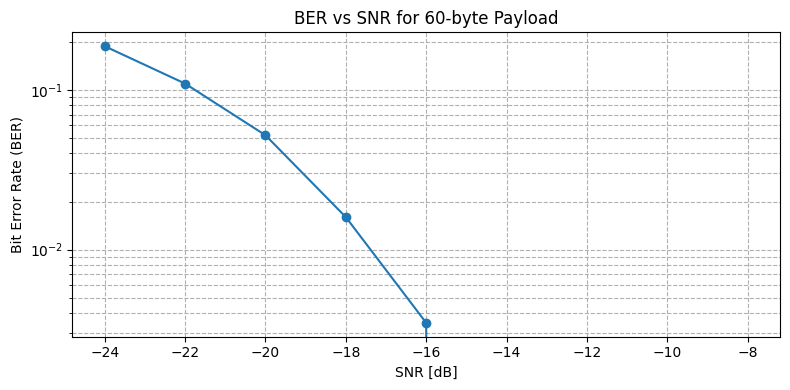

{-24: 0.1882, -22: 0.1097, -20: 0.0521, -18: 0.016, -16: 0.0035, -14: 0.0, -12: 0.0, -10: 0.0, -8: 0.0}


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. กำหนดค่าเริ่มต้นของข้อความ 60 ไบต์ และแปลงเป็นบิต
_rng = np.random.default_rng(7)
MSG60 = bytes(_rng.integers(32, 127, 60).tolist()).decode()
SENT60 = text_to_bits(MSG60)

# 2. นิยามฟังก์ชัน raw_ber
def raw_ber(y, sent_bits, baud=50, fs=FS):
    """Bit error rate with the payload length known."""
    start, _ = find_start(y, fs=fs)
    ns = int(round(fs / baud))
    payload_start = start + 8 * ns
    nbits = len(sent_bits)

    demodulated_bits, _, _ = demod_bits(y, payload_start, nbits, baud, fs=fs)

    errors = np.sum(demodulated_bits != sent_bits)
    ber = errors / nbits

    return ber

# 3. คำนวณ BER วนลูปตามช่วง SNR และ seed ที่กำหนด
snrs = np.arange(-24, -7, 2)
bers = []

for snr in snrs:
    ber_seeds = []
    for seed in [0, 1, 2]:
        y_sim = room_channel(transmit(MSG60, 50), snr_db=snr, drr_db=None, seed=seed)
        b = raw_ber(y_sim, SENT60, 50, FS)
        ber_seeds.append(b)
    bers.append(np.mean(ber_seeds))

bers = np.array(bers)

# 4. พล็อตผลลัพธ์ด้วย semilogy
plt.figure(figsize=(8, 4))
plt.semilogy(snrs, bers, marker='o')
plt.xlabel("SNR [dB]")
plt.ylabel("Bit Error Rate (BER)")
plt.title("BER vs SNR for 60-byte Payload")
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

print(dict(zip(snrs.tolist(), np.round(bers, 4).tolist())) if len(bers) else "not done")

### 3.5 Questions (2 pts)
(a) At SNR −10 dB the waveform looks like pure noise, yet the message decodes. Explain using the idea of looking only near two frequencies. *ทำไม SNR −10 dB ยังถอดได้ ทั้งที่ดูเหมือน noise ล้วน*
(b) What happens to the **whole message** if one of the 8 header bits is wrong? *ถ้าบิตของ header ผิดหนึ่งบิต ข้อความทั้งหมดจะเป็นอย่างไร*

✍️ **Your answer / คำตอบ:**

(a) แม้ว่ารูปคลื่นรวมจะดูเหมือนนอยส์ทั้งหมดเนื่องจากสัญญาณรบกวนกลบ แต่กระบวนการดีโมดูเลชันจะทำการกรองและตรวจสอบพลังงานเฉพาะที่ย่านความถี่เฉพาะตัวสองค่าคือ $F_0$ และ $F_1$ เท่านั้น (ผ่านการคำนวณ Coherent Detection / Tone Energy) ซึ่งพลังงานของนอยส์ส่วนใหญ่จะกระจายตัวอยู่ย่านความถี่อื่นและถูกหักล้างกันไปในการหาค่าปริพันธ์ (Integral/Summation) ทำให้ระบบยังคงสามารถแยกแยะพลังงานของโทนเสียงที่ถูกต้องและถอดรหัสข้อความออกมาได้

(b) หากบิตในส่วนของ header (ไบต์บอกความยาว) ผิดพลาดไปแม้แต่บิตเดียว ค่าตัวเลขจำนวนไบต์ที่ถอดรหัสออกมาได้จะคลาดเคลื่อนไปจากเดิมอย่างมาก ส่งผลให้ระบบไปอ่านขนาด payload ผิดพลาด ทำให้ข้อความทั้งหมดถูกถอดรหัสเพี้ยนไปหรืออ่านข้อมูลผิดตำแหน่งทั้งหมด

---
## Part 4 · Over the air (25 pts)
*ส่วนที่ 4 · ส่งผ่านอากาศจริง*

1. Run 4.1 to make `ota_message.wav` and download it to the laptop. *สร้างไฟล์และดาวน์โหลด*
2. Put the phone **0.5 m** from the laptop speaker. Start the phone’s voice recorder, play the WAV at medium volume, stop recording. *วางมือถือห่าง 0.5 m อัดเสียงขณะเล่นไฟล์*
3. Repeat at **1 m** and **2 m**. Transfer the 3 recordings to the laptop and upload them in 4.2. *ทำซ้ำที่ 1 และ 2 m แล้วอัปโหลด*

No phone or recorder? Swap roles: play `ota_message.wav` on the phone and use `record()` on the laptop. *สลับบทบาทได้*

> Full marks need **real recordings**. `MODE = "sim"` (simulated room) is accepted for at most **12 / 25** in this part.
> *คะแนนเต็มต้องใช้การอัดจริง โหมดจำลองได้สูงสุด 12/25*

In [27]:
OTA_TEXT = f"Team {TEAM_ID}: DSP over the air! สวัสดี"
ota_tx = transmit(OTA_TEXT, 50)
save_wav(ota_tx, "ota_message.wav", download=True)
OTA_BITS = text_to_bits(OTA_TEXT)
print(f"{len(OTA_BITS)} payload bits, {len(ota_tx)/FS:.1f} s")
display(Audio(ota_tx, rate=FS))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

416 payload bits, 8.9 s


### 4.2 Decode your recordings (15 pts)
Set `MODE = "real"` and upload the 3 recordings in distance order, or `MODE = "sim"` to use the room model. `recordings[d]` is a **list** of takes (1 real recording, or 5 simulated rooms — results at the edge of range vary a lot from room to room). For each distance, decode every take with `receive`, compute the payload BER against `OTA_BITS` (compare up to the shorter length, and count missing bits as errors), and store the **mean** BER in `results`. Plot BER vs distance.
*ถอดรหัสแต่ละระยะ คำนวณ BER แล้ว plot*

In [ ]:
import numpy as np

# 1. กำหนดค่าการตั้งค่าเริ่มต้น
MODE = "real"           # หรือ "sim" ตามที่ต้องการใช้งาน
DISTANCES = [0.5, 1.0, 2.0]

def payload_ber(sent, got):
    n = min(len(sent), len(got))
    return (np.sum(sent[:n] != got[:n]) + abs(len(sent) - len(got))) / len(sent)

recordings = {}   # distance → list of recordings (1 real take, or 5 simulated rooms)
for d in DISTANCES:
    if MODE == "real" and IN_COLAB:
        print(f"Upload the recording made at {d} m")
        recordings[d] = [load_recording(upload_file())]
    else:
        snr, drr = at_distance(d)
        recordings[d] = [room_channel(ota_tx, snr, drr_db=drr, seed=s) for s in range(5)]

# 2. ลูปคำนวณและประเมินผล BER
results = []  # rows: (distance, decoded text of the first take, mean BER over the takes)

for d in DISTANCES:
    takes_ber = []
    first_take_text = ""

    for i, y in enumerate(recordings[d]):
        # ถอดรหัสข้อความจากสัญญาณเสียง y
        text, got_bits = receive(y, baud=50, fs=FS)

        if i == 0:
            first_take_text = text

        # คำนวณ BER เปรียบเทียบกับ OTA_BITS
        start, _ = find_start(y, fs=FS)
        ns = int(round(FS / 50))
        got_payload_bits, _, _ = demod_bits(y, start + 8 * ns, len(OTA_BITS), 50, fs=FS)

        ber = payload_ber(OTA_BITS, got_payload_bits)
        takes_ber.append(ber)

    mean_ber = np.mean(takes_ber)
    results.append((d, first_take_text, mean_ber))

# 3. แสดงผลลัพธ์และตรวจสอบ
for d, text, b in results:
    print(f"{d:>4} m   BER {b:6.3f}   {text!r}")
check(len(results) == 3, "3 distances decoded")

Upload the recording made at 0.5 m


### 4.3 Look inside your worst recording (4 pts)
Plot the spectrogram (0–5000 Hz) of the recording with the highest BER, next to the one with the lowest. What is different? *เทียบ spectrogram ของไฟล์ที่ดีที่สุดกับแย่ที่สุด*

In [ ]:
# TODO

### 4.4 Questions (6 pts)
(a) How did BER change with distance? Give two physical reasons. *BER เปลี่ยนตามระยะอย่างไร ให้เหตุผลทางกายภาพ 2 ข้อ*
(b) In the worst spectrogram, what do you see between bits that is not in the transmitted signal? *เห็นอะไรระหว่างบิตที่ไม่มีในสัญญาณที่ส่ง*
(c) Name one thing your **phone** may do to the recording that the simulation does not model. *มือถืออาจทำอะไรกับเสียงที่การจำลองไม่ได้รวมไว้*

✍️ **Your answer / คำตอบ:**

(a)

(b)

(c)

---
## Part 5 · Challenge (15 pts)
*ส่วนที่ 5 · ภารกิจท้าทาย*

### 5.1 The leaderboard: fastest error-free link (8 pts)
Find the **highest bit rate** from `[50, 100, 200, 400, 800]` that delivers `RACE_TEXT` with **zero bit errors at 1 m or more**. Remember Δf · T_b must stay ≥ 1 for our tones (Part 2.4). Real recordings for the leaderboard; use `MODE` from Part 4. (In `sim` mode the race uses a noisy, low-echo room at SNR −12 dB, where speed clearly costs reliability.)
*หาความเร็วสูงสุดที่ส่งได้ไม่ผิดเลยที่ระยะอย่างน้อย 1 m แล้วส่งผลขึ้นกระดาน*

$$E_b = P\,T_b = \frac{P}{R} \qquad\Rightarrow\qquad \text{double } R \;\Rightarrow\; \text{about 3 dB more SNR needed}$$

In [ ]:
RACE_TEXT = "The quick brown fox jumps over the lazy dog 0123456789"
RACE_BITS = text_to_bits(RACE_TEXT)
RACE_DIST = 1.0
leaderboard = []   # rows: (baud, BER)

for baud in [50, 100, 200, 400, 800]:
    txb = transmit(RACE_TEXT, baud)
    if MODE == "real" and IN_COLAB:
        save_wav(txb, f"race_{baud}.wav", download=True)
        print(f"Play race_{baud}.wav at {RACE_DIST} m, record, then upload"); y = load_recording(upload_file())
    else:
        y = room_channel(txb, snr_db=-12, drr_db=None, seed=baud)   # sim: a noisy, low-echo room
    # TODO: decode with receive(y, baud) and append (baud, BER) to leaderboard

best = max([b for b, e in leaderboard if e == 0], default=None)
print(leaderboard, "→ fastest error-free:", best, "bit/s")
check(len(leaderboard) == 5, "all 5 bit rates tested")

### 5.2 Detect errors with a checksum byte (5 pts)
Append one **checksum byte** = (sum of all payload bytes) mod 256 after the payload (it is **not** counted in the length byte). On receive, recompute it and report whether the message is intact.
- `transmit_checked(text, baud)` and `receive_checked(y, baud)` → `(text, ok)`
*เพิ่มไบต์ checksum ต่อท้าย แล้วตรวจที่ฝั่งรับว่าข้อความถูกต้องหรือไม่*

In [ ]:
def checksum(bits):
    """Sum of the bytes, mod 256, as 8 bits."""
    total = int(np.sum(np.packbits(np.asarray(bits, dtype=np.uint8)).astype(int))) % 256
    return np.unpackbits(np.array([total], dtype=np.uint8))

def transmit_checked(text, baud=50, fs=FS):
    # TODO: like transmit, but the bits are frame_bits(text) + checksum(payload bits)
    return None

def receive_checked(y, baud=50, fs=FS):
    # TODO: like receive, then decode 8 more bits and compare with checksum(payload)
    return "", False

good = room_channel(transmit_checked("checksum test", 50), 0, drr_db=None, seed=2)
# simulate a bit error: overwrite frame bit 30 (payload bit 22) with the OTHER tone
bad = good.copy(); s0, _ = find_start(bad); seg = slice(s0 + 30 * 882, s0 + 31 * 882)
flip = fsk_modulate([1 - frame_bits("checksum test")[30]], 50); bad[seg] = flip * np.std(bad[seg]) / np.std(flip)
print(receive_checked(good), receive_checked(bad))
check(receive_checked(good) == ("checksum test", True), "intact message passes")
check(receive_checked(bad)[1] is False, "corrupted message is flagged")

### 5.3 Questions (2 pts)
(a) Give an example of two bit errors that this checksum would **miss**. *ยกตัวอย่างบิตผิด 2 บิตที่ checksum นี้ตรวจไม่พบ*
(b) A checksum only **detects** errors. What could the receiver do next, and what would a code that **corrects** errors cost you? *ตรวจพบแล้วทำอะไรต่อ และรหัสที่แก้ข้อผิดพลาดได้ต้องแลกกับอะไร*

✍️ **Your answer / คำตอบ:**

(a)

(b)

---
## Team reflection (not graded) / สะท้อนการเรียนรู้ของทีม
Which block of the system was hardest to get right? If your team picks capstone track C, what would you improve first?
*บล็อกไหนยากที่สุด ถ้าเลือกแทร็ก C จะปรับปรุงอะไรก่อน*

✍️ **Your answer / คำตอบ:**